CELL 0 — Install Libraries + Create Project Folders

In [1]:
# ============================================================
# CELL 0 — INSTALL LIBRARIES + CREATE PROJECT FOLDERS
# ============================================================

import sys
import subprocess
import os
import json
import shutil
import warnings
from pathlib import Path
from datetime import datetime

warnings.filterwarnings("ignore")

def install_package(package_name):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

print("Installing required libraries...")

required_packages = [
    "rdkit",
    "scikit-learn",
    "xgboost",
    "lightgbm",
    "umap-learn",
    "joblib",
    "tqdm"
]

for package in required_packages:
    install_package(package)

try:
    install_package("torch torchvision torchaudio")
    install_package("torch-geometric")
    GNN_INSTALL_OK = True
except Exception as error:
    print("GNN libraries could not be installed. Classical ML will still work.")
    print(error)
    GNN_INSTALL_OK = False

PROJECT_NAME = "HybridPXR_Net_Project"
BASE_DIR = Path(PROJECT_NAME)

folders = [
    "data/raw",
    "data/processed",
    "representations/descriptors",
    "representations/fingerprints",
    "representations/graphs",
    "splits",
    "models/random_forest",
    "models/xgboost",
    "models/lightgbm",
    "models/gnn",
    "models/ensemble",
    "predictions",
    "results",
    "tables",
    "plots/architecture",
    "plots/eda",
    "plots/umap",
    "plots/feature_importance",
    "plots/predictions",
    "plots/learning_curves",
    "plots/scaffolds",
    "deployment",
    "logs",
    "reports"
]

for folder in folders:
    (BASE_DIR / folder).mkdir(parents=True, exist_ok=True)

project_config = {
    "project_name": PROJECT_NAME,
    "created_at": datetime.now().isoformat(),
    "target_column": "pchembl_value",
    "smiles_column": "canonical_smiles",
    "architecture": "HybridPXR-Net: descriptors + fingerprints + graphs + ensemble regression"
}

with open(BASE_DIR / "project_config.json", "w") as f:
    json.dump(project_config, f, indent=4)

print("CELL 0 DONE")
print("Project folder created:", PROJECT_NAME)

Installing required libraries...
GNN libraries could not be installed. Classical ML will still work.
Command '['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'torch torchvision torchaudio']' returned non-zero exit status 1.
CELL 0 DONE
Project folder created: HybridPXR_Net_Project


CELL 1 — Data Acquisition with Upload Button

In [2]:
# ============================================================
# CELL 1 — DATA ACQUISITION WITH UPLOAD BUTTON
# ============================================================

import pandas as pd
import numpy as np
import os
from pathlib import Path

try:
    from google.colab import files

    print("Please upload your dataset CSV file now.")
    print("Example file name: chembl_admet_all.csv")

    uploaded = files.upload()

    if len(uploaded) == 0:
        raise FileNotFoundError("No file uploaded.")

    uploaded_file_name = list(uploaded.keys())[0]
    DATA_PATH = f"/content/{uploaded_file_name}"

except Exception as error:
    print("Upload button failed or not running in Colab.")
    print("Trying fallback paths...")

    possible_paths = [
        "/content/chembl_admet_all.csv",
        "chembl_admet_all.csv",
        "/mnt/data/chembl_admet_all.csv"
    ]

    DATA_PATH = None

    for path in possible_paths:
        if os.path.exists(path):
            DATA_PATH = path
            break

    if DATA_PATH is None:
        raise FileNotFoundError("Dataset not found. Please upload your CSV file.")

raw_df = pd.read_csv(DATA_PATH)

raw_df.to_csv(
    BASE_DIR / "data/raw/original_uploaded_dataset.csv",
    index=False
)

step1_summary = pd.DataFrame({
    "Item": ["Uploaded file", "Rows", "Columns", "Column names"],
    "Value": [
        DATA_PATH,
        raw_df.shape[0],
        raw_df.shape[1],
        ", ".join(raw_df.columns.astype(str))
    ]
})

step1_summary.to_csv(
    BASE_DIR / "tables/step1_data_acquisition_summary.csv",
    index=False
)

print("CELL 1 DONE")
print("Dataset loaded successfully.")
print("Shape:", raw_df.shape)

raw_df.head()

Please upload your dataset CSV file now.
Example file name: chembl_admet_all.csv


Saving chembl_admet_all.csv to chembl_admet_all.csv
CELL 1 DONE
Dataset loaded successfully.
Shape: (2452576, 9)


,chembl_id,canonical_smiles,assay_type,assay_description,standard_type,standard_relation,standard_value,standard_units,pchembl_value
0,CHEMBL157101,CC(=O)N1CCN(c2ccc(OCC3COC(Cn4ccnc4)(c4ccc(Cl)c...,A,Inhibition of cytochrome P450 progesterone 15-...,IC50,=,369.0,nM,6.43
1,CHEMBL328863,CC(=O)N1CCN(c2ccc(OC[C@@H]3CO[C@](Cn4ccnc4)(c4...,A,Inhibition of cytochrome P450 progesterone 15-...,IC50,=,728.0,nM,6.14
2,CHEMBL319160,CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@@](Cn4ccnc4)(c4...,A,Inhibition of cytochrome P450 progesterone 15-...,IC50,=,1080.0,nM,5.97
3,CHEMBL157101,CC(=O)N1CCN(c2ccc(OCC3COC(Cn4ccnc4)(c4ccc(Cl)c...,A,Inhibition of cytochrome P450 progesterone 15-...,IC50,=,543.0,nM,6.26
4,CHEMBL157101,CC(=O)N1CCN(c2ccc(OCC3COC(Cn4ccnc4)(c4ccc(Cl)c...,A,Inhibition of cytochrome P450 progesterone 16-...,IC50,=,69300.0,nM,4.16


CELL 2 — Data Preprocessing

In [3]:
# ============================================================
# CELL 2 — DATA PREPROCESSING
# ============================================================

from rdkit import Chem
from tqdm.auto import tqdm

tqdm.pandas()

required_columns = [
    "canonical_smiles",
    "assay_description",
    "pchembl_value"
]

missing_columns = [
    col for col in required_columns
    if col not in raw_df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

pxr_keywords = [
    "pxr",
    "pregnane x receptor",
    "pregnane-x receptor",
    "nr1i2",
    "pregnane receptor"
]

keyword_pattern = "|".join(pxr_keywords)

pxr_df = raw_df[
    raw_df["assay_description"]
    .astype(str)
    .str.lower()
    .str.contains(keyword_pattern, na=False)
].copy()

print("Initial PXR-related rows found:", len(pxr_df))

if len(pxr_df) < 50:
    print("WARNING: Few PXR-specific rows found.")
    print("Using EC50 / IC50 / AC50 fallback subset so the full pipeline can run.")
    print("For final research, replace this with the official PXR challenge dataset.")

    pxr_df = raw_df.dropna(
        subset=["canonical_smiles", "pchembl_value"]
    ).copy()

    if "standard_type" in pxr_df.columns:
        pxr_df = pxr_df[
            pxr_df["standard_type"]
            .astype(str)
            .str.upper()
            .isin(["EC50", "IC50", "AC50"])
        ]

    pxr_df = pxr_df.sample(
        n=min(5000, len(pxr_df)),
        random_state=42
    ).copy()

pxr_df = pxr_df.dropna(
    subset=["canonical_smiles", "pchembl_value"]
)

pxr_df["pchembl_value"] = pd.to_numeric(
    pxr_df["pchembl_value"],
    errors="coerce"
)

pxr_df = pxr_df.dropna(subset=["pchembl_value"])

def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(str(smiles))

        if mol is None:
            return None

        return Chem.MolToSmiles(mol, canonical=True)

    except Exception:
        return None

pxr_df["canonical_smiles"] = pxr_df["canonical_smiles"].progress_apply(
    canonicalize_smiles
)

pxr_df = pxr_df.dropna(subset=["canonical_smiles"])

aggregation_rules = {
    "pchembl_value": "mean",
    "assay_description": lambda x: " | ".join(
        list(map(str, x.unique()))[:3]
    )
}

if "chembl_id" in pxr_df.columns:
    aggregation_rules["chembl_id"] = "first"

full_df = pxr_df.groupby(
    "canonical_smiles",
    as_index=False
).agg(aggregation_rules).reset_index(drop=True)

full_df.to_csv(
    BASE_DIR / "data/processed/step2_clean_pxr_dataset.csv",
    index=False
)

step2_summary = pd.DataFrame({
    "Item": [
        "Raw rows",
        "Filtered assay rows",
        "Unique clean molecules",
        "Mean pChEMBL",
        "Std pChEMBL",
        "Min pChEMBL",
        "Max pChEMBL"
    ],
    "Value": [
        len(raw_df),
        len(pxr_df),
        len(full_df),
        full_df["pchembl_value"].mean(),
        full_df["pchembl_value"].std(),
        full_df["pchembl_value"].min(),
        full_df["pchembl_value"].max()
    ]
})

step2_summary.to_csv(
    BASE_DIR / "tables/step2_preprocessing_summary.csv",
    index=False
)

print("CELL 2 DONE")
print("Clean dataset shape:", full_df.shape)

step2_summary

Initial PXR-related rows found: 1893


  0%|          | 0/589 [00:00<?, ?it/s]

CELL 2 DONE
Clean dataset shape: (430, 4)


,Item,Value
0,Raw rows,2.452576e+06
1,Filtered assay rows,5.890000e+02
2,Unique clean molecules,4.300000e+02
3,Mean pChEMBL,5.555388e+00
4,Std pChEMBL,7.015755e-01
5,Min pChEMBL,4.110000e+00
6,Max pChEMBL,8.100000e+00


CELL 3 — Molecular Descriptors

In [4]:
# ============================================================
# CELL 3 — MOLECULAR REPRESENTATION A: RDKit DESCRIPTORS
# ============================================================

from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors

def compute_rdkit_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return {
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "NumHDonors": Lipinski.NumHDonors(mol),
        "NumHAcceptors": Lipinski.NumHAcceptors(mol),
        "NumRotatableBonds": Lipinski.NumRotatableBonds(mol),
        "RingCount": rdMolDescriptors.CalcNumRings(mol),
        "AromaticRingCount": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "HeavyAtomCount": Descriptors.HeavyAtomCount(mol)
    }

descriptor_records = []

for smiles in tqdm(full_df["canonical_smiles"], desc="Generating RDKit descriptors"):
    descriptor_records.append(compute_rdkit_descriptors(smiles))

desc_df = pd.DataFrame(descriptor_records)

full_df = pd.concat(
    [full_df.reset_index(drop=True), desc_df.reset_index(drop=True)],
    axis=1
).dropna().reset_index(drop=True)

feature_cols = desc_df.columns.tolist()

desc_df.to_csv(
    BASE_DIR / "representations/descriptors/step3_rdkit_descriptors.csv",
    index=False
)

full_df.to_csv(
    BASE_DIR / "data/processed/step3_dataset_with_descriptors.csv",
    index=False
)

print("CELL 3 DONE")
print("Descriptor matrix shape:", desc_df.shape)

desc_df.head()

Generating RDKit descriptors:   0%|          | 0/430 [00:00<?, ?it/s]

CELL 3 DONE
Descriptor matrix shape: (430, 10)


,MolWt,LogP,TPSA,NumHDonors,NumHAcceptors,NumRotatableBonds,RingCount,AromaticRingCount,FractionCSP3,HeavyAtomCount
0,394.740,4.5581,23.47,1,2,0,4,2,0.368421,23
1,385.265,3.9725,50.28,1,5,3,4,3,0.222222,24
2,382.423,3.3518,68.51,1,4,6,4,4,0.086957,29
3,341.370,3.7846,59.53,1,3,4,4,4,0.047619,26
4,327.468,4.1437,52.82,2,3,1,4,0,0.761905,24


CELL 4 — ECFP4 Fingerprints

In [5]:
# ============================================================
# CELL 4 — MOLECULAR REPRESENTATION B: ECFP4 FINGERPRINTS
# ============================================================

from rdkit.Chem import AllChem, DataStructs

def generate_ecfp4(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    fingerprint = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius,
        nBits=n_bits
    )

    arr = np.zeros((n_bits,), dtype=np.int8)

    DataStructs.ConvertToNumpyArray(
        fingerprint,
        arr
    )

    return arr

fingerprints = []
valid_indices = []

for index, smiles in enumerate(
    tqdm(full_df["canonical_smiles"], desc="Generating ECFP4 fingerprints")
):
    fp = generate_ecfp4(smiles)

    if fp is not None:
        fingerprints.append(fp)
        valid_indices.append(index)

fps = np.asarray(fingerprints, dtype=np.int8)

full_df = full_df.iloc[valid_indices].reset_index(drop=True)

np.save(
    BASE_DIR / "representations/fingerprints/step4_ecfp4_2048.npy",
    fps
)

full_df.to_csv(
    BASE_DIR / "data/processed/step4_dataset_with_fingerprints.csv",
    index=False
)

print("CELL 4 DONE")
print("Fingerprint matrix shape:", fps.shape)

Generating ECFP4 fingerprints:   0%|          | 0/430 [00:00<?, ?it/s]

[05:18:22] DEPRECATION WARNING: please use MorganGenerator
[05:18:22] DEPRECATION WARNING: please use MorganGenerator
[05:18:22] DEPRECATION WARNING: please use MorganGenerator
[05:18:22] DEPRECATION WARNING: please use MorganGenerator
[05:18:22] DEPRECATION WARNING: please use MorganGenerator
[05:18:22] DEPRECATION WARNING: please use MorganGenerator
[05:18:22] DEPRECATION WARNING: please use MorganGenerator
[05:18:22] DEPRECATION WARNING: please use MorganGenerator
[05:18:22] DEPRECATION WARNING: please use MorganGenerator
[05:18:22] DEPRECATION WARNING: please use MorganGenerator
[05:18:22] DEPRECATION WARNING: please use MorganGenerator
[05:18:22] DEPRECATION WARNING: please use MorganGenerator
[05:18:22] DEPRECATION WARNING: please use MorganGenerator
[05:18:22] DEPRECATION WARNING: please use MorganGenerator
[05:18:22] DEPRECATION WARNING: please use MorganGenerator
[05:18:22] DEPRECATION WARNING: please use MorganGenerator
[05:18:22] DEPRECATION WARNING: please use MorganGenerat

CELL 4 DONE
Fingerprint matrix shape: (430, 2048)


CELL 5 — Molecular Graph Construction

In [6]:
# ============================================================
# CELL 5 — MOLECULAR REPRESENTATION C: MOLECULAR GRAPHS
# ============================================================

try:
    import torch
    from torch_geometric.data import Data

    PYG_AVAILABLE = True

except Exception as error:
    print("PyTorch Geometric is unavailable.")
    print("The GNN model will be skipped.")
    print(error)

    PYG_AVAILABLE = False


def atom_features(atom):
    return [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetFormalCharge(),
        int(atom.GetHybridization()),
        int(atom.GetIsAromatic())
    ]


def mol_to_graph(smiles, y_value):

    if not PYG_AVAILABLE:
        return None

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    node_features = []

    for atom in mol.GetAtoms():
        node_features.append(atom_features(atom))

    x = torch.tensor(
        node_features,
        dtype=torch.float
    )

    edges = []

    for bond in mol.GetBonds():
        start = bond.GetBeginAtomIdx()
        end = bond.GetEndAtomIdx()

        edges.append([start, end])
        edges.append([end, start])

    if len(edges) > 0:
        edge_index = torch.tensor(
            edges,
            dtype=torch.long
        ).t().contiguous()
    else:
        edge_index = torch.empty(
            (2, 0),
            dtype=torch.long
        )

    y = torch.tensor(
        [float(y_value)],
        dtype=torch.float
    )

    graph = Data(
        x=x,
        edge_index=edge_index,
        y=y
    )

    return graph


graph_dataset = []

if PYG_AVAILABLE:

    for _, row in tqdm(
        full_df.iterrows(),
        total=len(full_df),
        desc="Building molecular graphs"
    ):

        graph = mol_to_graph(
            row["canonical_smiles"],
            row["pchembl_value"]
        )

        if graph is not None:
            graph_dataset.append(graph)

    torch.save(
        graph_dataset,
        BASE_DIR / "representations/graphs/step5_graph_dataset.pt"
    )


step5_summary = pd.DataFrame({
    "Representation": [
        "RDKit descriptors",
        "ECFP4 fingerprints",
        "Molecular graphs"
    ],
    "Output": [
        str(desc_df.shape),
        str(fps.shape),
        len(graph_dataset)
    ]
})

step5_summary.to_csv(
    BASE_DIR / "tables/step5_molecular_representation_summary.csv",
    index=False
)

print("CELL 5 DONE")
step5_summary

PyTorch Geometric is unavailable.
The GNN model will be skipped.
No module named 'torch_geometric'
CELL 5 DONE


,Representation,Output
0,RDKit descriptors,"(430, 10)"
1,ECFP4 fingerprints,"(430, 2048)"
2,Molecular graphs,0


CELL 6 — Scaffold Split

In [7]:
# ============================================================
# CELL 6 — DATA SPLITTING: BEMIS-MURCKO SCAFFOLD SPLIT
# ============================================================

from rdkit.Chem.Scaffolds import MurckoScaffold

def get_bemis_murcko_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return "INVALID"

    try:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

    except Exception:
        return "INVALID"


full_df["scaffold"] = full_df["canonical_smiles"].apply(
    get_bemis_murcko_scaffold
)

scaffold_groups = full_df.groupby("scaffold").indices

scaffold_sets = sorted(
    scaffold_groups.values(),
    key=lambda x: len(x),
    reverse=True
)

total_molecules = len(full_df)

train_cutoff = int(0.80 * total_molecules)
valid_cutoff = int(0.90 * total_molecules)

train_indices = []
valid_indices = []
test_indices = []

for scaffold_group in scaffold_sets:

    scaffold_group = list(scaffold_group)

    if len(train_indices) + len(scaffold_group) <= train_cutoff:
        train_indices.extend(scaffold_group)

    elif len(train_indices) + len(valid_indices) + len(scaffold_group) <= valid_cutoff:
        valid_indices.extend(scaffold_group)

    else:
        test_indices.extend(scaffold_group)


train_df = full_df.iloc[train_indices].reset_index(drop=True)
valid_df = full_df.iloc[valid_indices].reset_index(drop=True)
test_df = full_df.iloc[test_indices].reset_index(drop=True)


train_df.to_csv(
    BASE_DIR / "splits/step6_train_scaffold.csv",
    index=False
)

valid_df.to_csv(
    BASE_DIR / "splits/step6_valid_scaffold.csv",
    index=False
)

test_df.to_csv(
    BASE_DIR / "splits/step6_test_scaffold.csv",
    index=False
)


step6_summary = pd.DataFrame({
    "Split": [
        "Train",
        "Validation",
        "Test"
    ],
    "Molecules": [
        len(train_df),
        len(valid_df),
        len(test_df)
    ],
    "Unique scaffolds": [
        train_df["scaffold"].nunique(),
        valid_df["scaffold"].nunique(),
        test_df["scaffold"].nunique()
    ]
})

step6_summary.to_csv(
    BASE_DIR / "tables/step6_scaffold_split_summary.csv",
    index=False
)

print("CELL 6 DONE")
step6_summary

CELL 6 DONE


,Split,Molecules,Unique scaffolds
0,Train,344,184
1,Validation,43,43
2,Test,43,43


CELL 7 — Prepare Model Inputs

In [8]:
# ============================================================
# CELL 7 — PREPARE MODEL INPUT MATRICES
# ============================================================

from sklearn.preprocessing import StandardScaler
import joblib

fp_lookup = {
    smiles: fps[index]
    for index, smiles in enumerate(full_df["canonical_smiles"])
}

def make_model_matrix(df, use_descriptors=True, use_fingerprints=True):
    matrix_parts = []

    if use_descriptors:
        descriptor_matrix = df[feature_cols].values.astype(float)
        matrix_parts.append(descriptor_matrix)

    if use_fingerprints:
        fingerprint_matrix = np.vstack([
            fp_lookup[smiles]
            for smiles in df["canonical_smiles"]
        ]).astype(float)

        matrix_parts.append(fingerprint_matrix)

    return np.hstack(matrix_parts)

X_train = make_model_matrix(train_df)
X_valid = make_model_matrix(valid_df)
X_test = make_model_matrix(test_df)

y_train = train_df["pchembl_value"].values
y_valid = valid_df["pchembl_value"].values
y_test = test_df["pchembl_value"].values

scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

joblib.dump(
    scaler,
    BASE_DIR / "models/ensemble/feature_scaler.pkl"
)

print("CELL 7 DONE")
print("Training matrix:", X_train_scaled.shape)
print("Validation matrix:", X_valid_scaled.shape)
print("Test matrix:", X_test_scaled.shape)

CELL 7 DONE
Training matrix: (344, 2058)
Validation matrix: (43, 2058)
Test matrix: (43, 2058)


CELL 8 — Train Parallel Classical Models

In [9]:
# ============================================================
# CELL 8 — LEARNING MODULES: PARALLEL CLASSICAL MODELS
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# ----------------------------
# Random Forest
# ----------------------------

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    max_features="sqrt"
)

rf_model.fit(X_train_scaled, y_train)

rf_valid_pred = rf_model.predict(X_valid_scaled)
rf_test_pred = rf_model.predict(X_test_scaled)

joblib.dump(
    rf_model,
    BASE_DIR / "models/random_forest/step8_random_forest_model.pkl"
)

print("Random Forest trained.")

# ----------------------------
# XGBoost
# ----------------------------

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_scaled, y_train)

xgb_valid_pred = xgb_model.predict(X_valid_scaled)
xgb_test_pred = xgb_model.predict(X_test_scaled)

joblib.dump(
    xgb_model,
    BASE_DIR / "models/xgboost/step8_xgboost_model.pkl"
)

print("XGBoost trained.")

# ----------------------------
# LightGBM
# ----------------------------

try:
    from lightgbm import LGBMRegressor

    lgbm_model = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    lgbm_model.fit(X_train_scaled, y_train)

    lgbm_valid_pred = lgbm_model.predict(X_valid_scaled)
    lgbm_test_pred = lgbm_model.predict(X_test_scaled)

    joblib.dump(
        lgbm_model,
        BASE_DIR / "models/lightgbm/step8_lightgbm_model.pkl"
    )

    LIGHTGBM_AVAILABLE = True

    print("LightGBM trained.")

except Exception as error:
    print("LightGBM skipped.")
    print(error)

    lgbm_model = None
    lgbm_valid_pred = None
    lgbm_test_pred = None
    LIGHTGBM_AVAILABLE = False

print("CELL 8 DONE")

Random Forest trained.
XGBoost trained.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001418 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 796
[LightGBM] [Info] Number of data points in the train set: 344, number of used features: 172
[LightGBM] [Info] Start training from score 5.579738
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further

CELL 9 — Optional GNN Model

In [10]:
# ============================================================
# CELL 9 — OPTIONAL GRAPH NEURAL NETWORK MODEL
# ============================================================

GNN_AVAILABLE = False

if PYG_AVAILABLE and len(graph_dataset) >= 50:

    try:
        import torch
        import torch.nn.functional as F
        from torch_geometric.loader import DataLoader
        from torch_geometric.nn import GCNConv, global_mean_pool
        from sklearn.model_selection import train_test_split

        class GCNRegressor(torch.nn.Module):
            def __init__(self, input_dim=5, hidden_dim=128):
                super().__init__()

                self.conv1 = GCNConv(input_dim, hidden_dim)
                self.conv2 = GCNConv(hidden_dim, hidden_dim)

                self.fc1 = torch.nn.Linear(hidden_dim, 64)
                self.fc2 = torch.nn.Linear(64, 1)

            def forward(self, x, edge_index, batch):
                x = self.conv1(x, edge_index)
                x = F.relu(x)

                x = self.conv2(x, edge_index)
                x = F.relu(x)

                x = global_mean_pool(x, batch)

                x = self.fc1(x)
                x = F.relu(x)

                x = self.fc2(x)

                return x.view(-1)

        train_graphs, temp_graphs = train_test_split(
            graph_dataset,
            test_size=0.20,
            random_state=42
        )

        valid_graphs, test_graphs = train_test_split(
            temp_graphs,
            test_size=0.50,
            random_state=42
        )

        train_loader = DataLoader(
            train_graphs,
            batch_size=32,
            shuffle=True
        )

        gnn_model = GCNRegressor(
            input_dim=5,
            hidden_dim=128
        )

        optimizer = torch.optim.Adam(
            gnn_model.parameters(),
            lr=0.001
        )

        criterion = torch.nn.MSELoss()

        gnn_history = []

        for epoch in range(1, 21):

            gnn_model.train()

            total_loss = 0

            for batch in train_loader:

                optimizer.zero_grad()

                predictions = gnn_model(
                    batch.x,
                    batch.edge_index,
                    batch.batch
                )

                loss = criterion(
                    predictions,
                    batch.y.view(-1)
                )

                loss.backward()

                optimizer.step()

                total_loss += loss.item()

            average_loss = total_loss / max(1, len(train_loader))

            gnn_history.append({
                "epoch": epoch,
                "train_loss": average_loss
            })

            print(f"Epoch {epoch:02d} | GNN training loss: {average_loss:.4f}")

        torch.save(
            gnn_model.state_dict(),
            BASE_DIR / "models/gnn/step9_gcn_regressor_model.pth"
        )

        pd.DataFrame(gnn_history).to_csv(
            BASE_DIR / "results/step9_gnn_training_history.csv",
            index=False
        )

        GNN_AVAILABLE = True

        print("GNN trained and saved.")

    except Exception as error:
        print("GNN skipped because an error occurred.")
        print(error)

else:
    print("GNN skipped because PyTorch Geometric is unavailable or graph dataset is too small.")

print("CELL 9 DONE")

GNN skipped because PyTorch Geometric is unavailable or graph dataset is too small.
CELL 9 DONE


CELL 10 — Prediction Output and Ensemble

In [11]:
# ============================================================
# CELL 10 — PREDICTION OUTPUT AND ENSEMBLE MODEL
# ============================================================

valid_predictions = {
    "RandomForest": rf_valid_pred,
    "XGBoost": xgb_valid_pred
}

test_predictions = {
    "RandomForest": rf_test_pred,
    "XGBoost": xgb_test_pred
}

if LIGHTGBM_AVAILABLE:
    valid_predictions["LightGBM"] = lgbm_valid_pred
    test_predictions["LightGBM"] = lgbm_test_pred

ensemble_valid_pred = np.mean(
    np.vstack(list(valid_predictions.values())),
    axis=0
)

ensemble_test_pred = np.mean(
    np.vstack(list(test_predictions.values())),
    axis=0
)

prediction_output_df = test_df[
    ["canonical_smiles", "pchembl_value", "scaffold"]
].copy()

if "chembl_id" in test_df.columns:
    prediction_output_df.insert(
        0,
        "chembl_id",
        test_df["chembl_id"]
    )

for model_name, prediction_values in test_predictions.items():
    prediction_output_df[f"pred_{model_name}"] = prediction_values

prediction_output_df["pred_Ensemble"] = ensemble_test_pred

prediction_output_df["absolute_error_Ensemble"] = np.abs(
    prediction_output_df["pchembl_value"] -
    prediction_output_df["pred_Ensemble"]
)

prediction_output_df.to_csv(
    BASE_DIR / "predictions/step10_test_predictions_all_models.csv",
    index=False
)

print("CELL 10 DONE")
prediction_output_df.head()

CELL 10 DONE


,chembl_id,canonical_smiles,pchembl_value,scaffold,pred_RandomForest,pred_XGBoost,pred_LightGBM,pred_Ensemble,absolute_error_Ensemble
0,CHEMBL1324157,COc1ccccc1-c1nnc(NC(C)=O)s1,4.96,c1ccc(-c2nncs2)cc1,5.443912,5.393832,5.669789,5.502511,0.542511
1,CHEMBL1600251,Cc1cc(C)nc(Nc2ncc(O)n2-c2ccccc2)n1,5.03,c1ccc(-n2ccnc2Nc2ncccn2)cc1,5.214106,5.063222,4.918831,5.065387,0.035387
2,CHEMBL1111,COC(c1ccccc1)(c1ccccc1)[C@H](Oc1nc(C)cc(C)n1)C...,4.50,c1ccc(C(COc2ncccn2)c2ccccc2)cc1,5.307586,5.309685,5.359658,5.325643,0.825643
3,CHEMBL3827928,O[C@H](c1ccccn1)C1(c2ccc(OC(F)(F)F)cc2)CC(F)(F)C1,5.24,c1ccc(C2(Cc3ccccn3)CCC2)cc1,5.356995,5.289237,4.863690,5.169974,0.070026
4,CHEMBL1714574,CC(C)N1CCN(c2ccc(OCC3COC(Cn4cncn4)(c4ccc(Cl)cc...,4.98,c1ccc(C2(Cn3cncn3)OCC(COc3ccc(N4CCNCC4)cc3)O2)cc1,5.354983,5.629172,5.438217,5.474124,0.494124


CELL 11 — Evaluation Metrics

In [12]:
# ============================================================
# CELL 11 — EVALUATION METRICS
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

def calculate_regression_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
        "Pearson": float(pearsonr(y_true, y_pred)[0]) if len(y_true) > 2 else np.nan,
        "Spearman": float(spearmanr(y_true, y_pred)[0]) if len(y_true) > 2 else np.nan
    }

metric_rows = []

for model_name, prediction_values in test_predictions.items():
    row = calculate_regression_metrics(y_test, prediction_values)
    row["Model"] = model_name
    metric_rows.append(row)

ensemble_row = calculate_regression_metrics(y_test, ensemble_test_pred)
ensemble_row["Model"] = "Ensemble"
metric_rows.append(ensemble_row)

metrics_df = pd.DataFrame(metric_rows)[
    ["Model", "MAE", "RMSE", "R2", "Pearson", "Spearman"]
]

metrics_df.to_csv(
    BASE_DIR / "results/step11_model_evaluation_metrics.csv",
    index=False
)

print("CELL 11 DONE")
metrics_df

CELL 11 DONE


,Model,MAE,RMSE,R2,Pearson,Spearman
0,RandomForest,0.523957,0.643297,0.047886,0.247389,0.153974
1,XGBoost,0.547346,0.711677,-0.165283,0.057200,-0.029904
2,LightGBM,0.591373,0.738678,-0.255384,0.039906,-0.022881
3,Ensemble,0.542036,0.684855,-0.079105,0.097414,0.017142


CELL 12 — Analysis and Visualization

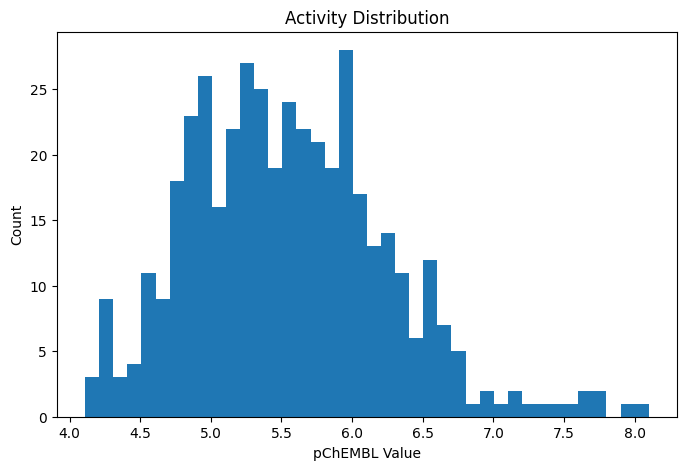

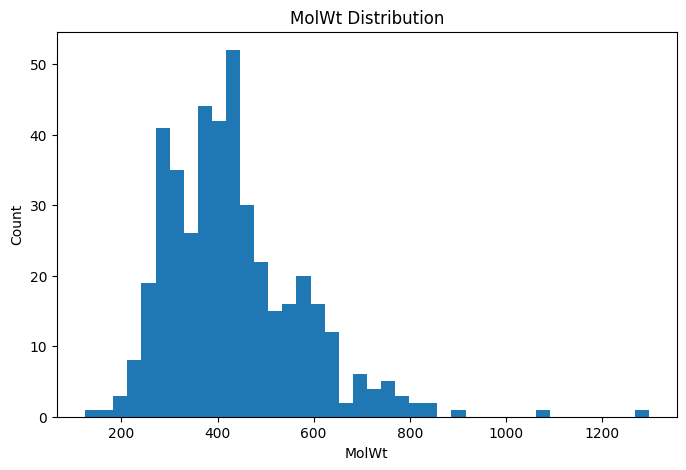

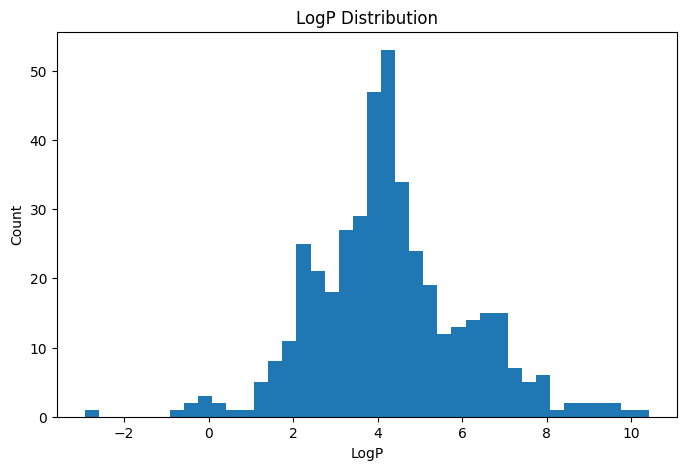

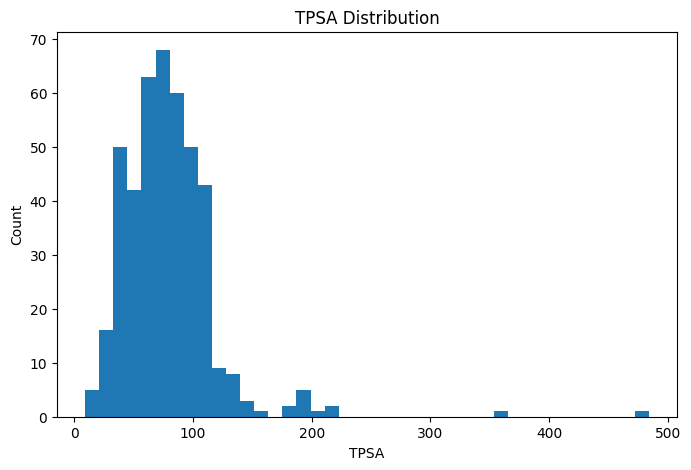

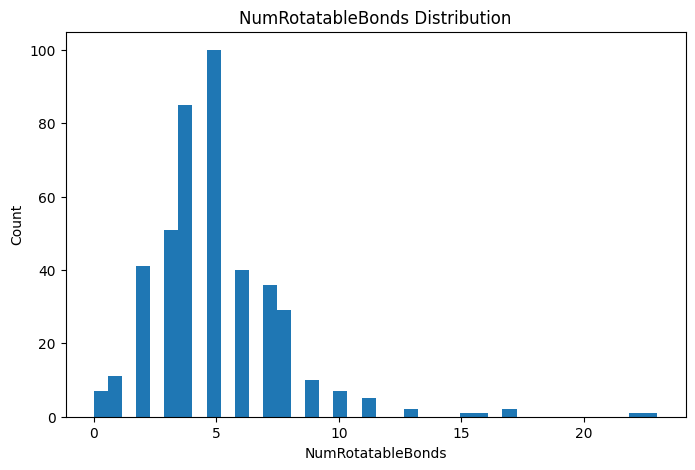

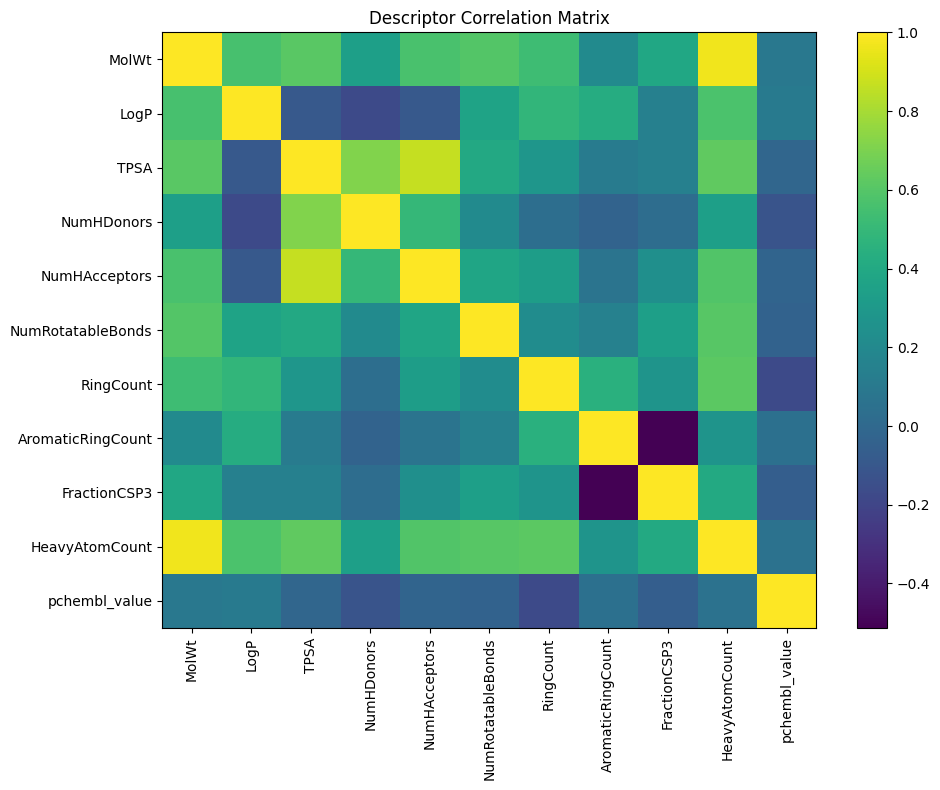

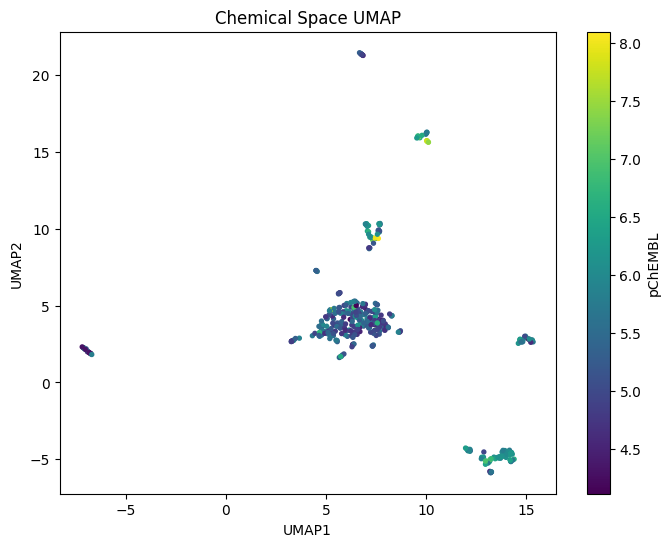

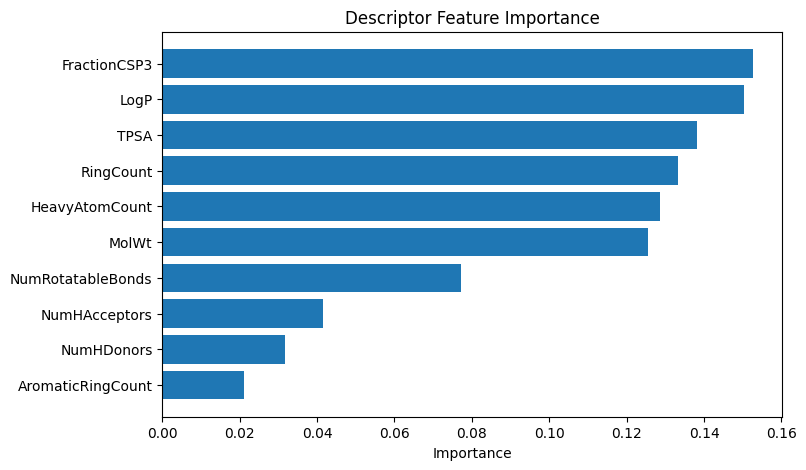

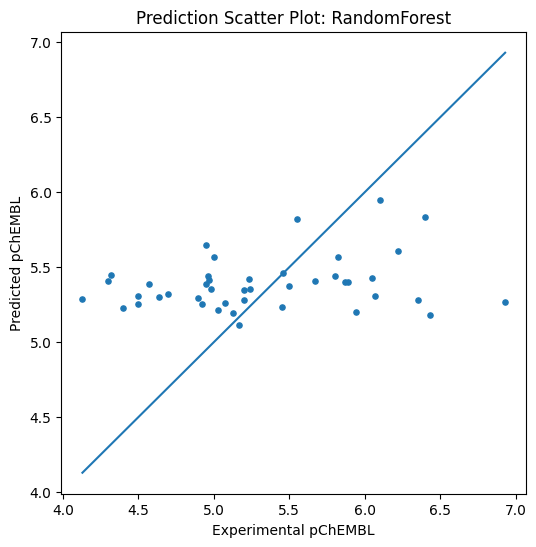

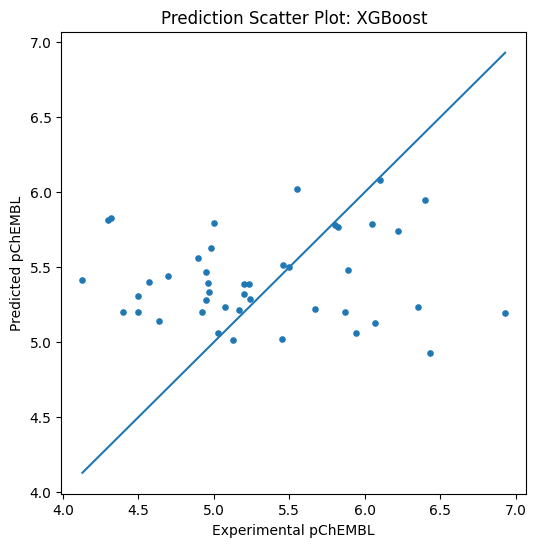

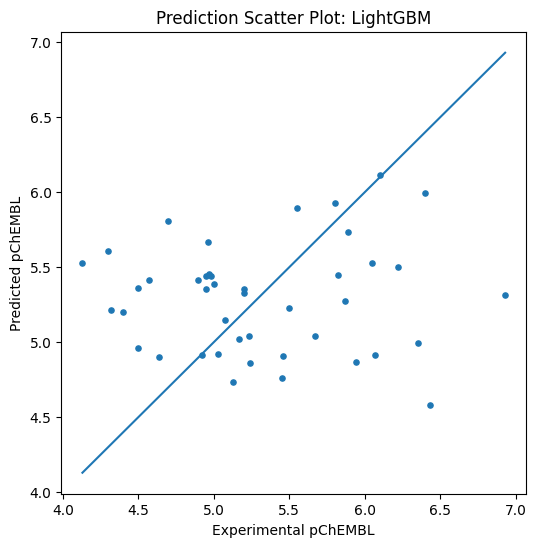

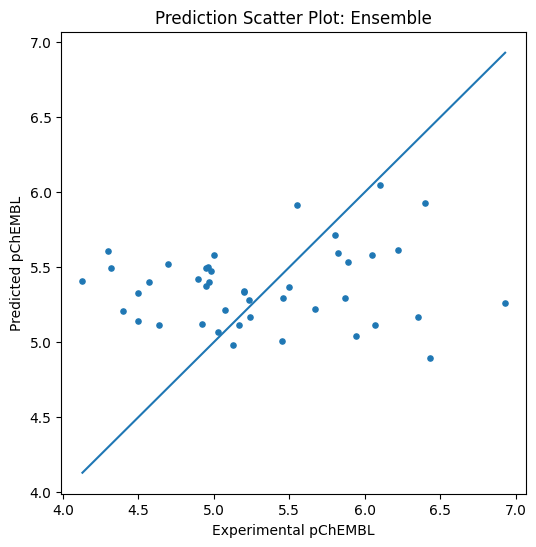

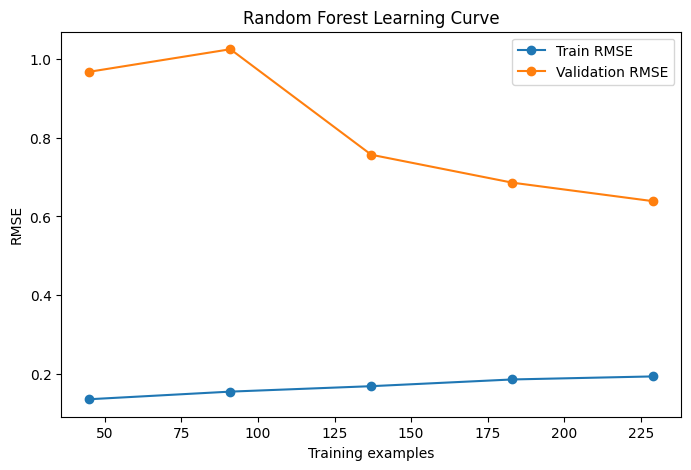

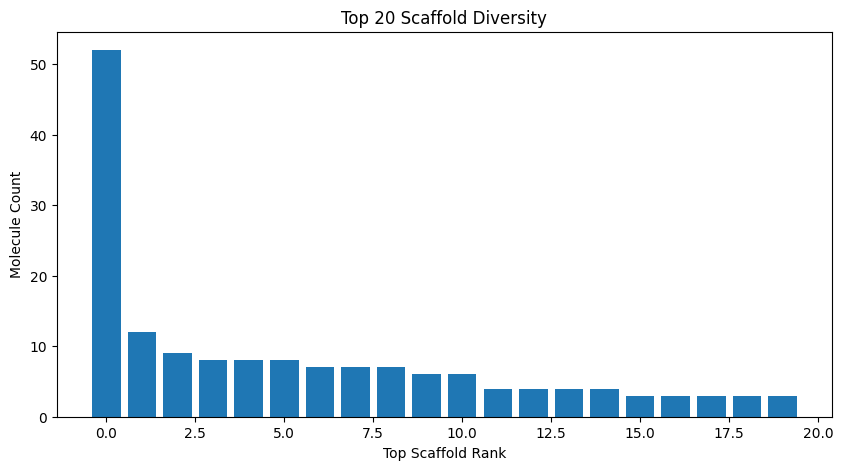

CELL 12 DONE


In [13]:
# ============================================================
# CELL 12 — ANALYSIS AND VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

# ----------------------------
# 12A Activity Distribution
# ----------------------------

plt.figure(figsize=(8, 5))
plt.hist(full_df["pchembl_value"], bins=40)
plt.xlabel("pChEMBL Value")
plt.ylabel("Count")
plt.title("Activity Distribution")

plt.savefig(
    BASE_DIR / "plots/eda/step12_activity_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ----------------------------
# 12B Descriptor Distributions
# ----------------------------

for descriptor_name in ["MolWt", "LogP", "TPSA", "NumRotatableBonds"]:

    plt.figure(figsize=(8, 5))
    plt.hist(full_df[descriptor_name], bins=40)
    plt.xlabel(descriptor_name)
    plt.ylabel("Count")
    plt.title(f"{descriptor_name} Distribution")

    plt.savefig(
        BASE_DIR / f"plots/eda/step12_{descriptor_name}_distribution.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ----------------------------
# 12C Descriptor Correlation Matrix
# ----------------------------

correlation_matrix = full_df[
    feature_cols + ["pchembl_value"]
].corr()

correlation_matrix.to_csv(
    BASE_DIR / "tables/step12_descriptor_correlation_matrix.csv"
)

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, aspect="auto")
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)
plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)
plt.colorbar()
plt.title("Descriptor Correlation Matrix")
plt.tight_layout()

plt.savefig(
    BASE_DIR / "plots/eda/step12_descriptor_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ----------------------------
# 12D Chemical Space UMAP
# ----------------------------

try:
    import umap

    sample_size = min(5000, len(fps))

    random_generator = np.random.default_rng(42)

    sample_indices = random_generator.choice(
        len(fps),
        size=sample_size,
        replace=False
    )

    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        random_state=42
    )

    embedding = reducer.fit_transform(
        fps[sample_indices]
    )

    umap_df = pd.DataFrame({
        "UMAP1": embedding[:, 0],
        "UMAP2": embedding[:, 1],
        "pchembl_value": full_df.iloc[sample_indices]["pchembl_value"].values,
        "canonical_smiles": full_df.iloc[sample_indices]["canonical_smiles"].values
    })

    umap_df.to_csv(
        BASE_DIR / "tables/step12_chemical_space_umap_coordinates.csv",
        index=False
    )

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        umap_df["UMAP1"],
        umap_df["UMAP2"],
        c=umap_df["pchembl_value"],
        s=8
    )

    plt.colorbar(scatter, label="pChEMBL")
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title("Chemical Space UMAP")

    plt.savefig(
        BASE_DIR / "plots/umap/step12_chemical_space_umap.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

except Exception as error:
    print("UMAP skipped.")
    print(error)


# ----------------------------
# 12E Feature Importance
# ----------------------------

from sklearn.ensemble import RandomForestRegressor

rf_descriptor_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_descriptor_model.fit(
    train_df[feature_cols].values,
    y_train
)

joblib.dump(
    rf_descriptor_model,
    BASE_DIR / "models/random_forest/step12_random_forest_descriptors_only.pkl"
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_descriptor_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance_df.to_csv(
    BASE_DIR / "tables/step12_descriptor_feature_importance.csv",
    index=False
)

plt.figure(figsize=(8, 5))
plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Descriptor Feature Importance")

plt.savefig(
    BASE_DIR / "plots/feature_importance/step12_descriptor_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ----------------------------
# 12F Prediction Scatter Plots
# ----------------------------

for model_name in list(test_predictions.keys()) + ["Ensemble"]:

    if model_name == "Ensemble":
        current_prediction = ensemble_test_pred
    else:
        current_prediction = test_predictions[model_name]

    plt.figure(figsize=(6, 6))
    plt.scatter(
        y_test,
        current_prediction,
        s=14
    )

    min_value = min(
        np.min(y_test),
        np.min(current_prediction)
    )

    max_value = max(
        np.max(y_test),
        np.max(current_prediction)
    )

    plt.plot(
        [min_value, max_value],
        [min_value, max_value]
    )

    plt.xlabel("Experimental pChEMBL")
    plt.ylabel("Predicted pChEMBL")
    plt.title(f"Prediction Scatter Plot: {model_name}")

    plt.savefig(
        BASE_DIR / f"plots/predictions/step12_prediction_scatter_{model_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ----------------------------
# 12G Learning Curve
# ----------------------------

from sklearn.model_selection import learning_curve

learning_sample_size = min(
    3000,
    X_train_scaled.shape[0]
)

train_sizes, train_scores, validation_scores = learning_curve(
    RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    X_train_scaled[:learning_sample_size],
    y_train[:learning_sample_size],
    cv=3,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

learning_curve_df = pd.DataFrame({
    "train_size": train_sizes,
    "train_rmse": np.sqrt(-train_scores.mean(axis=1)),
    "validation_rmse": np.sqrt(-validation_scores.mean(axis=1))
})

learning_curve_df.to_csv(
    BASE_DIR / "results/step12_random_forest_learning_curve.csv",
    index=False
)

plt.figure(figsize=(8, 5))
plt.plot(
    learning_curve_df["train_size"],
    learning_curve_df["train_rmse"],
    marker="o",
    label="Train RMSE"
)

plt.plot(
    learning_curve_df["train_size"],
    learning_curve_df["validation_rmse"],
    marker="o",
    label="Validation RMSE"
)

plt.xlabel("Training examples")
plt.ylabel("RMSE")
plt.title("Random Forest Learning Curve")
plt.legend()

plt.savefig(
    BASE_DIR / "plots/learning_curves/step12_random_forest_learning_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ----------------------------
# 12H Scaffold Diversity
# ----------------------------

top_scaffolds_df = full_df[
    "scaffold"
].value_counts().head(20).reset_index()

top_scaffolds_df.columns = [
    "Scaffold",
    "Count"
]

top_scaffolds_df.to_csv(
    BASE_DIR / "tables/step12_top_20_scaffolds.csv",
    index=False
)

plt.figure(figsize=(10, 5))
plt.bar(
    range(len(top_scaffolds_df)),
    top_scaffolds_df["Count"]
)

plt.xlabel("Top Scaffold Rank")
plt.ylabel("Molecule Count")
plt.title("Top 20 Scaffold Diversity")

plt.savefig(
    BASE_DIR / "plots/scaffolds/step12_top_20_scaffold_diversity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("CELL 12 DONE")

UPDATED CELL 12G — LEARNING CURVES FOR ALL MODELS

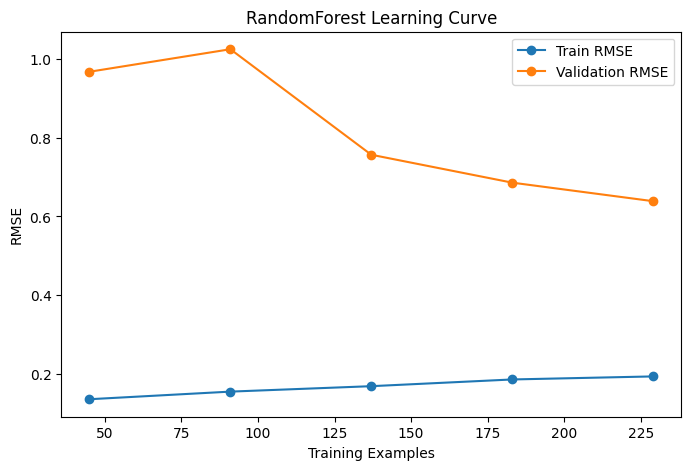

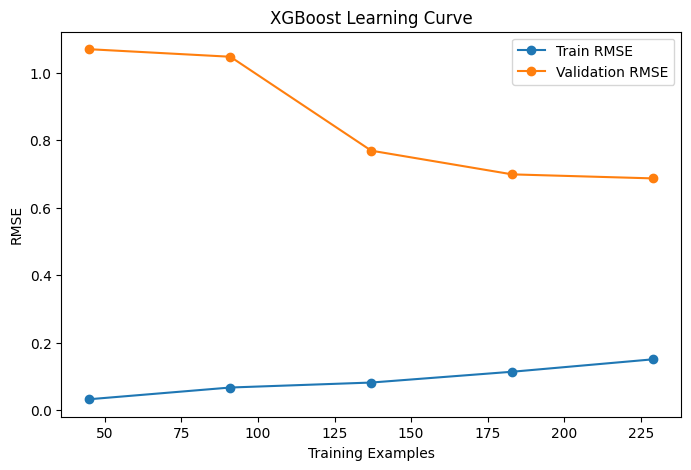

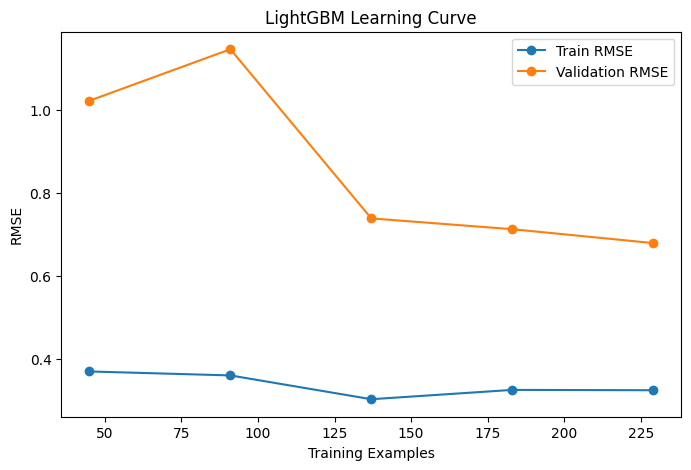

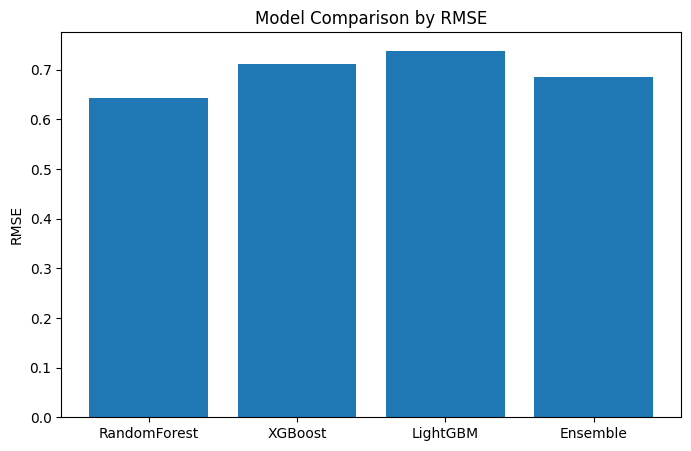

STEP 12G UPDATED DONE


In [22]:
# ============================================================
# STEP 12G — LEARNING CURVES FOR ALL MODELS
# ============================================================

from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def save_learning_curve(
    model,
    model_name,
    X,
    y,
    save_folder
):

    train_sizes, train_scores, validation_scores = learning_curve(
        model,
        X,
        y,
        cv=3,
        scoring="neg_mean_squared_error",
        train_sizes=np.linspace(0.2, 1.0, 5),
        n_jobs=-1
    )

    learning_curve_df = pd.DataFrame({
        "train_size": train_sizes,
        "train_rmse": np.sqrt(-train_scores.mean(axis=1)),
        "validation_rmse": np.sqrt(-validation_scores.mean(axis=1))
    })

    # Save CSV
    learning_curve_df.to_csv(
        save_folder / f"{model_name}_learning_curve.csv",
        index=False
    )

    # Plot
    plt.figure(figsize=(8, 5))

    plt.plot(
        learning_curve_df["train_size"],
        learning_curve_df["train_rmse"],
        marker="o",
        label="Train RMSE"
    )

    plt.plot(
        learning_curve_df["train_size"],
        learning_curve_df["validation_rmse"],
        marker="o",
        label="Validation RMSE"
    )

    plt.xlabel("Training Examples")
    plt.ylabel("RMSE")
    plt.title(f"{model_name} Learning Curve")
    plt.legend()

    plt.savefig(
        save_folder / f"{model_name}_learning_curve.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return learning_curve_df


# ------------------------------------------------------------
# Sample size for faster computation
# ------------------------------------------------------------

learning_sample_size = min(
    3000,
    X_train_scaled.shape[0]
)

X_learning = X_train_scaled[:learning_sample_size]
y_learning = y_train[:learning_sample_size]


# ------------------------------------------------------------
# Random Forest Learning Curve
# ------------------------------------------------------------

rf_learning_df = save_learning_curve(
    RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "RandomForest",
    X_learning,
    y_learning,
    BASE_DIR / "plots/learning_curves"
)


# ------------------------------------------------------------
# XGBoost Learning Curve
# ------------------------------------------------------------

xgb_learning_df = save_learning_curve(
    XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=6,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost",
    X_learning,
    y_learning,
    BASE_DIR / "plots/learning_curves"
)


# ------------------------------------------------------------
# LightGBM Learning Curve
# ------------------------------------------------------------

if LIGHTGBM_AVAILABLE:

    from lightgbm import LGBMRegressor

    lgbm_learning_df = save_learning_curve(
        LGBMRegressor(
            n_estimators=100,
            learning_rate=0.05,
            random_state=42,
            n_jobs=-1
        ),
        "LightGBM",
        X_learning,
        y_learning,
        BASE_DIR / "plots/learning_curves"
    )


# ------------------------------------------------------------
# Ensemble Comparison Plot
# ------------------------------------------------------------

ensemble_metrics_df = metrics_df.copy()

plt.figure(figsize=(8, 5))

plt.bar(
    ensemble_metrics_df["Model"],
    ensemble_metrics_df["RMSE"]
)

plt.ylabel("RMSE")
plt.title("Model Comparison by RMSE")

plt.savefig(
    BASE_DIR / "plots/learning_curves/model_rmse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ensemble_metrics_df.to_csv(
    BASE_DIR / "results/model_rmse_comparison.csv",
    index=False
)

print("STEP 12G UPDATED DONE")

CELL 12G-2 — Ensemble Learning Curve

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000030 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 73
[LightGBM] [Info] Number of data points in the train set: 45, number of used features: 8
[LightGBM] [Info] Start training from score 6.192667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

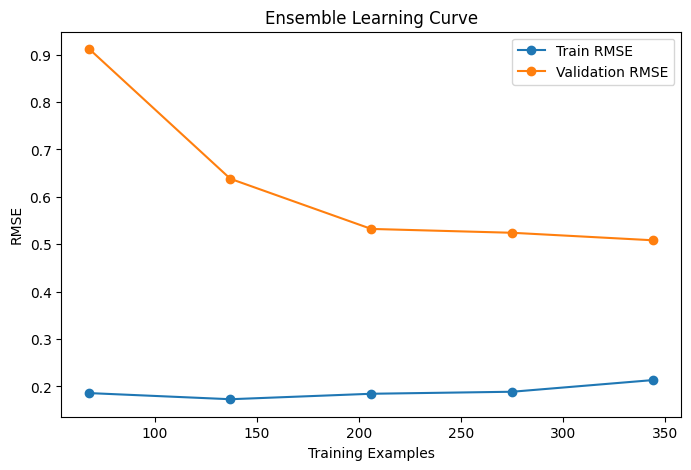

CELL 12G-2 DONE


,train_fraction,train_examples,train_rmse,validation_rmse
0,0.2,68,0.186024,0.911434
1,0.4,137,0.173112,0.638091
2,0.6,206,0.184628,0.532340
3,0.8,275,0.188886,0.524234
4,1.0,344,0.213523,0.508387


In [23]:
# ============================================================
# CELL 12G-2 — TRUE ENSEMBLE LEARNING CURVE
# ============================================================

from sklearn.base import clone
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ensemble_learning_curve(X, y, train_sizes, cv=3):
    rows = []

    kfold = KFold(
        n_splits=cv,
        shuffle=True,
        random_state=42
    )

    for train_size in train_sizes:

        train_rmse_scores = []
        valid_rmse_scores = []

        for train_index, valid_index in kfold.split(X):

            X_train_fold = X[train_index]
            X_valid_fold = X[valid_index]

            y_train_fold = y[train_index]
            y_valid_fold = y[valid_index]

            # Use only part of training fold
            subset_size = int(train_size * len(X_train_fold))

            X_train_subset = X_train_fold[:subset_size]
            y_train_subset = y_train_fold[:subset_size]

            # Define models
            rf_temp = RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )

            xgb_temp = XGBRegressor(
                n_estimators=100,
                learning_rate=0.05,
                max_depth=6,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )

            models = [rf_temp, xgb_temp]

            if LIGHTGBM_AVAILABLE:
                from lightgbm import LGBMRegressor

                lgbm_temp = LGBMRegressor(
                    n_estimators=100,
                    learning_rate=0.05,
                    random_state=42,
                    n_jobs=-1
                )

                models.append(lgbm_temp)

            train_predictions = []
            valid_predictions = []

            for model in models:
                model.fit(X_train_subset, y_train_subset)

                train_predictions.append(
                    model.predict(X_train_subset)
                )

                valid_predictions.append(
                    model.predict(X_valid_fold)
                )

            ensemble_train_pred = np.mean(
                np.vstack(train_predictions),
                axis=0
            )

            ensemble_valid_pred = np.mean(
                np.vstack(valid_predictions),
                axis=0
            )

            train_rmse = np.sqrt(
                mean_squared_error(y_train_subset, ensemble_train_pred)
            )

            valid_rmse = np.sqrt(
                mean_squared_error(y_valid_fold, ensemble_valid_pred)
            )

            train_rmse_scores.append(train_rmse)
            valid_rmse_scores.append(valid_rmse)

        rows.append({
            "train_fraction": train_size,
            "train_examples": int(train_size * len(X)),
            "train_rmse": np.mean(train_rmse_scores),
            "validation_rmse": np.mean(valid_rmse_scores)
        })

    return pd.DataFrame(rows)


ensemble_train_fractions = np.linspace(0.2, 1.0, 5)

ensemble_learning_df = ensemble_learning_curve(
    X_learning,
    y_learning,
    ensemble_train_fractions,
    cv=3
)

ensemble_learning_df.to_csv(
    BASE_DIR / "plots/learning_curves/Ensemble_learning_curve.csv",
    index=False
)

ensemble_learning_df.to_csv(
    BASE_DIR / "results/Ensemble_learning_curve.csv",
    index=False
)

plt.figure(figsize=(8, 5))

plt.plot(
    ensemble_learning_df["train_examples"],
    ensemble_learning_df["train_rmse"],
    marker="o",
    label="Train RMSE"
)

plt.plot(
    ensemble_learning_df["train_examples"],
    ensemble_learning_df["validation_rmse"],
    marker="o",
    label="Validation RMSE"
)

plt.xlabel("Training Examples")
plt.ylabel("RMSE")
plt.title("Ensemble Learning Curve")
plt.legend()

plt.savefig(
    BASE_DIR / "plots/learning_curves/Ensemble_learning_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("CELL 12G-2 DONE")
ensemble_learning_df

CELL 12X — Save Architecture + Verify All Outputs

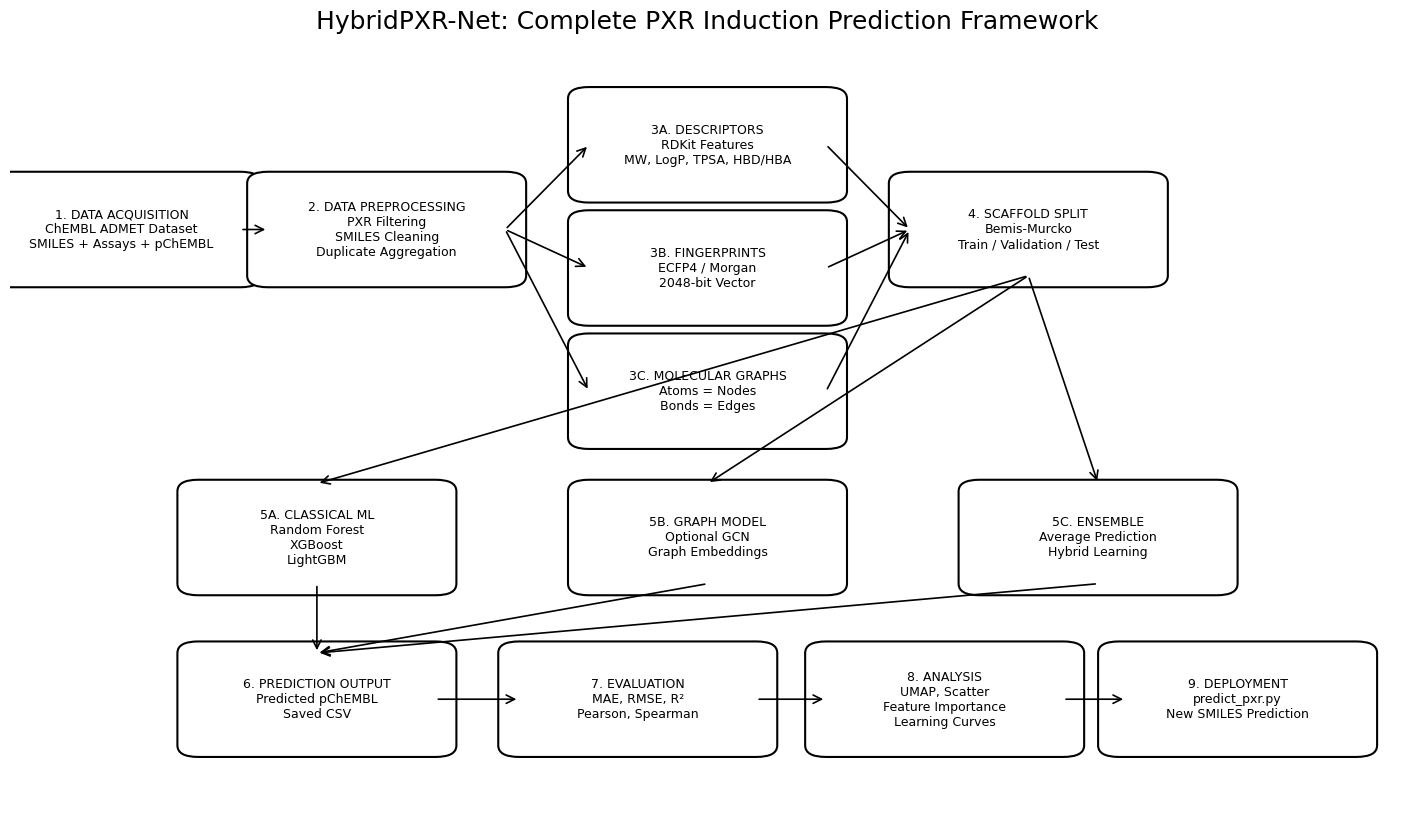

Architecture figure saved:
HybridPXR_Net_Project/plots/architecture/hybridpxr_net_architecture.png
HybridPXR_Net_Project/plots/architecture/hybridpxr_net_architecture.pdf
Total saved files: 64


,folder,file,path,size_kb
0,HybridPXR_Net_Project,README.md,HybridPXR_Net_Project/README.md,0.72
1,HybridPXR_Net_Project,project_config.json,HybridPXR_Net_Project/project_config.json,0.26
2,HybridPXR_Net_Project/predictions,final_test_predictions_all_models.csv,HybridPXR_Net_Project/predictions/final_test_p...,7.47
3,HybridPXR_Net_Project/predictions,step10_test_predictions_all_models.csv,HybridPXR_Net_Project/predictions/step10_test_...,7.47
4,HybridPXR_Net_Project/plots/predictions,step12_prediction_scatter_RandomForest.png,HybridPXR_Net_Project/plots/predictions/step12...,107.50
...,...,...,...,...
59,HybridPXR_Net_Project/models/xgboost,step8_xgboost_model.pkl,HybridPXR_Net_Project/models/xgboost/step8_xgb...,928.96
60,HybridPXR_Net_Project/models/lightgbm,step8_lightgbm_model.pkl,HybridPXR_Net_Project/models/lightgbm/step8_li...,701.10
61,HybridPXR_Net_Project/models/random_forest,step12_random_forest_descriptors_only.pkl,HybridPXR_Net_Project/models/random_forest/ste...,8549.63
62,HybridPXR_Net_Project/models/random_forest,step8_random_forest_model.pkl,HybridPXR_Net_Project/models/random_forest/ste...,9011.44


In [24]:
# ============================================================
# CELL 12X — SAVE ARCHITECTURE FIGURE + VERIFY ALL OUTPUTS
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import os
from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# 12X-A Professional architecture diagram
# ------------------------------------------------------------

plt.figure(figsize=(18, 10))
ax = plt.gca()
ax.axis("off")

boxes = [
    (0.08, 0.75, "1. DATA ACQUISITION\nChEMBL ADMET Dataset\nSMILES + Assays + pChEMBL"),
    (0.27, 0.75, "2. DATA PREPROCESSING\nPXR Filtering\nSMILES Cleaning\nDuplicate Aggregation"),
    (0.50, 0.86, "3A. DESCRIPTORS\nRDKit Features\nMW, LogP, TPSA, HBD/HBA"),
    (0.50, 0.70, "3B. FINGERPRINTS\nECFP4 / Morgan\n2048-bit Vector"),
    (0.50, 0.54, "3C. MOLECULAR GRAPHS\nAtoms = Nodes\nBonds = Edges"),
    (0.73, 0.75, "4. SCAFFOLD SPLIT\nBemis-Murcko\nTrain / Validation / Test"),
    (0.22, 0.35, "5A. CLASSICAL ML\nRandom Forest\nXGBoost\nLightGBM"),
    (0.50, 0.35, "5B. GRAPH MODEL\nOptional GCN\nGraph Embeddings"),
    (0.78, 0.35, "5C. ENSEMBLE\nAverage Prediction\nHybrid Learning"),
    (0.22, 0.14, "6. PREDICTION OUTPUT\nPredicted pChEMBL\nSaved CSV"),
    (0.45, 0.14, "7. EVALUATION\nMAE, RMSE, R²\nPearson, Spearman"),
    (0.67, 0.14, "8. ANALYSIS\nUMAP, Scatter\nFeature Importance\nLearning Curves"),
    (0.88, 0.14, "9. DEPLOYMENT\npredict_pxr.py\nNew SMILES Prediction")
]

for x, y, text in boxes:
    rect = FancyBboxPatch(
        (x - 0.085, y - 0.06),
        0.17,
        0.12,
        boxstyle="round,pad=0.015",
        linewidth=1.5,
        facecolor="white"
    )
    ax.add_patch(rect)
    ax.text(
        x,
        y,
        text,
        ha="center",
        va="center",
        fontsize=9
    )

arrows = [
    ((0.165, 0.75), (0.185, 0.75)),
    ((0.355, 0.75), (0.415, 0.86)),
    ((0.355, 0.75), (0.415, 0.70)),
    ((0.355, 0.75), (0.415, 0.54)),
    ((0.585, 0.86), (0.645, 0.75)),
    ((0.585, 0.70), (0.645, 0.75)),
    ((0.585, 0.54), (0.645, 0.75)),
    ((0.73, 0.69), (0.22, 0.42)),
    ((0.73, 0.69), (0.50, 0.42)),
    ((0.73, 0.69), (0.78, 0.42)),
    ((0.22, 0.29), (0.22, 0.20)),
    ((0.50, 0.29), (0.22, 0.20)),
    ((0.78, 0.29), (0.22, 0.20)),
    ((0.305, 0.14), (0.365, 0.14)),
    ((0.535, 0.14), (0.585, 0.14)),
    ((0.755, 0.14), (0.80, 0.14))
]

for start, end in arrows:
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="->",
        mutation_scale=15,
        linewidth=1.2
    )
    ax.add_patch(arrow)

plt.title(
    "HybridPXR-Net: Complete PXR Induction Prediction Framework",
    fontsize=18
)

architecture_png = BASE_DIR / "plots/architecture/hybridpxr_net_architecture.png"
architecture_pdf = BASE_DIR / "plots/architecture/hybridpxr_net_architecture.pdf"

plt.savefig(
    architecture_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    architecture_pdf,
    bbox_inches="tight"
)

plt.show()

print("Architecture figure saved:")
print(architecture_png)
print(architecture_pdf)


# ------------------------------------------------------------
# 12X-B Save all model metrics again
# ------------------------------------------------------------

metrics_df.to_csv(
    BASE_DIR / "results/final_model_evaluation_metrics.csv",
    index=False
)

prediction_output_df.to_csv(
    BASE_DIR / "predictions/final_test_predictions_all_models.csv",
    index=False
)

feature_importance_df.to_csv(
    BASE_DIR / "tables/final_descriptor_feature_importance.csv",
    index=False
)

learning_curve_df.to_csv(
    BASE_DIR / "results/final_random_forest_learning_curve.csv",
    index=False
)

top_scaffolds_df.to_csv(
    BASE_DIR / "tables/final_top_20_scaffolds.csv",
    index=False
)


# ------------------------------------------------------------
# 12X-C Save file inventory
# ------------------------------------------------------------

saved_files = []

for root, dirs, files in os.walk(BASE_DIR):
    for file in files:
        file_path = Path(root) / file
        saved_files.append({
            "folder": str(Path(root)),
            "file": file,
            "path": str(file_path),
            "size_kb": round(file_path.stat().st_size / 1024, 2)
        })

saved_files_df = pd.DataFrame(saved_files)

saved_files_df.to_csv(
    BASE_DIR / "reports/saved_file_inventory.csv",
    index=False
)

print("Total saved files:", len(saved_files_df))

saved_files_df

CELL 13 — Deployment Script

In [25]:
# ============================================================
# CELL 13 — DEPLOYMENT AND APPLICATION SCRIPT
# ============================================================

deployment_script = '''
import numpy as np
import joblib
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors, AllChem, DataStructs

def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        raise ValueError("Invalid SMILES")

    return np.array([
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        rdMolDescriptors.CalcTPSA(mol),
        Lipinski.NumHDonors(mol),
        Lipinski.NumHAcceptors(mol),
        Lipinski.NumRotatableBonds(mol),
        rdMolDescriptors.CalcNumRings(mol),
        rdMolDescriptors.CalcNumAromaticRings(mol),
        rdMolDescriptors.CalcFractionCSP3(mol),
        Descriptors.HeavyAtomCount(mol)
    ], dtype=float)

def generate_ecfp4(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        raise ValueError("Invalid SMILES")

    fingerprint = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius,
        nBits=n_bits
    )

    arr = np.zeros((n_bits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fingerprint, arr)

    return arr.astype(float)

def featurize(smiles):
    descriptor_vector = compute_descriptors(smiles)
    fingerprint_vector = generate_ecfp4(smiles)

    return np.hstack([
        descriptor_vector,
        fingerprint_vector
    ]).reshape(1, -1)

def predict_pxr(smiles, project_dir="HybridPXR_Net_Project"):
    scaler = joblib.load(
        f"{project_dir}/models/ensemble/feature_scaler.pkl"
    )

    rf_model = joblib.load(
        f"{project_dir}/models/random_forest/step8_random_forest_model.pkl"
    )

    xgb_model = joblib.load(
        f"{project_dir}/models/xgboost/step8_xgboost_model.pkl"
    )

    X = scaler.transform(
        featurize(smiles)
    )

    predictions = [
        rf_model.predict(X)[0],
        xgb_model.predict(X)[0]
    ]

    try:
        lgbm_model = joblib.load(
            f"{project_dir}/models/lightgbm/step8_lightgbm_model.pkl"
        )

        predictions.append(
            lgbm_model.predict(X)[0]
        )

    except Exception:
        pass

    return {
        "SMILES": smiles,
        "Predicted_pChEMBL_Ensemble": float(np.mean(predictions)),
        "Individual_Model_Predictions": [float(value) for value in predictions]
    }

if __name__ == "__main__":
    example_smiles = "CCO"
    print(predict_pxr(example_smiles))
'''

with open(
    BASE_DIR / "deployment/predict_pxr.py",
    "w"
) as file:
    file.write(deployment_script)

print("CELL 13 DONE")
print("Deployment script saved at:")
print(BASE_DIR / "deployment/predict_pxr.py")

CELL 13 DONE
Deployment script saved at:
HybridPXR_Net_Project/deployment/predict_pxr.py


CELL 14 — Save Final Report and Download ZIP

In [26]:
# ============================================================
# CELL 14 — SAVE FINAL PROJECT AND DOWNLOAD ZIP
# ============================================================

# Save final modeling dataset
full_df.to_csv(
    BASE_DIR / "data/processed/final_modeling_dataset.csv",
    index=False
)

# Save final report table
final_report_df = pd.DataFrame({
    "Step": [
        "1. Data Acquisition",
        "2. Data Preprocessing",
        "3. Molecular Representations",
        "4. Scaffold Split",
        "5. Learning Modules",
        "6. Prediction Output",
        "7. Evaluation Metrics",
        "8. Analysis and Visualization",
        "9. Deployment and Application"
    ],
    "Main saved outputs": [
        "data/raw/original_uploaded_dataset.csv",
        "data/processed/step2_clean_pxr_dataset.csv",
        "representations/descriptors, representations/fingerprints, representations/graphs",
        "splits/step6_train_scaffold.csv, step6_valid_scaffold.csv, step6_test_scaffold.csv",
        "models/random_forest, models/xgboost, models/lightgbm, models/gnn",
        "predictions/step10_test_predictions_all_models.csv",
        "results/step11_model_evaluation_metrics.csv",
        "plots, tables, results",
        "deployment/predict_pxr.py, final ZIP"
    ]
})

final_report_df.to_csv(
    BASE_DIR / "reports/final_project_report.csv",
    index=False
)

# Save README
readme_text = f"""
# HybridPXR-Net Project

This is a complete beginner-friendly Google Colab project for PXR induction / ADMET activity prediction.

## Project Architecture

1. Data Acquisition
2. Data Preprocessing
3. Molecular Representations
   - RDKit descriptors
   - ECFP4 fingerprints
   - Molecular graphs
4. Scaffold Split
5. Learning Modules
   - Random Forest
   - XGBoost
   - LightGBM
   - Optional GNN
   - Ensemble
6. Prediction Output
7. Evaluation Metrics
8. Analysis and Visualization
9. Deployment and Application

## Main Output Folders

- data/
- representations/
- splits/
- models/
- predictions/
- results/
- tables/
- plots/
- deployment/
- reports/
- logs/

## Target

pChEMBL regression.

Created at: {datetime.now().isoformat()}
"""

with open(
    BASE_DIR / "README.md",
    "w"
) as file:
    file.write(readme_text)

# Save project log
with open(
    BASE_DIR / "logs/project_run_log.txt",
    "w"
) as file:
    file.write("HybridPXR-Net project completed successfully.\\n")
    file.write(f"Final molecule count: {len(full_df)}\\n")
    file.write(f"Train molecules: {len(train_df)}\\n")
    file.write(f"Validation molecules: {len(valid_df)}\\n")
    file.write(f"Test molecules: {len(test_df)}\\n")
    file.write("\\nEvaluation metrics:\\n")
    file.write(metrics_df.to_string(index=False))

# Create ZIP
zip_path = shutil.make_archive(
    PROJECT_NAME,
    "zip",
    PROJECT_NAME
)

print("CELL 14 DONE")
print("Full project ZIP created:")
print(zip_path)

# Download ZIP in Google Colab
try:
    from google.colab import files
    files.download(f"{PROJECT_NAME}.zip")
except Exception:
    print("Not running inside Google Colab. ZIP saved locally.")

CELL 14 DONE
Full project ZIP created:
/content/HybridPXR_Net_Project.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>